# 이산 푸리에 변환 (DFT) — Python 실습

## 학습 목표
- FT → DTFT → DFT의 관계를 시각적으로 이해한다
- DFT 공식을 직접 구현하고 `np.fft.fft()`와 결과를 비교한다
- FFT로 cos파의 양측/단측 스펙트럼을 비교한다
- 주파수 분해능 $\Delta f = 1/T$의 의미를 체감한다
- DFT의 주기적 확장 가정을 시각화한다
`fftfreq`, `rfftfreq`, `fftshift` 사용법을 익힌다
- 스펙트럼 누설이 발생하는 조건을 직접 확인한다
- 합성 음성의 FFT 스펙트럼을 분석한다
- FFT 기반 노이즈 필터링을 실습한다

---
## 환경 설정

공통 스타일 모듈 `utils.style`을 불러온다.  
`COLORS`와 `LINE_COLORS`는 모든 실습에서 일관된 색상 팔레트를 제공한다.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from utils.style import setup_notebook, COLORS, LINE_COLORS
setup_notebook()

from utils import fft, fft_full, composite_signal, add_noise, fft_filter, stem_plot

---
## 사전 학습: NumPy FFT 함수

`numpy.fft` 핵심 함수들을 **변환 함수 ↔ 주파수 축 함수**의 짝으로 묶어서 살펴본다. 각 그룹은 "개념·호출" 셀과 "시각화" 셀로 나누어 단계적으로 확인한다.

| 그룹 | 주제 | 변환 함수 | 주파수 축 / 보조 |
|------|------|-----------|--------------------|
| **A1, A2** | 양측 스펙트럼 (전개 → x축 정렬) | `np.fft.fft` | `np.fft.fftfreq`, `np.fft.fftshift` |
| **B1, B2** | 역 DFT (호출 → 시간 복원 확인) | `np.fft.ifft` | — |
| **C1, C2** | 단측 스펙트럼 (호출 → 진폭 정규화) | `np.fft.rfft` | `np.fft.rfftfreq` |
| **D1, D2** | 실수 역 DFT (호출 → 시간 복원 확인) | `np.fft.irfft` | — |

> **참고**: 오디오·진동·센서 등 현실 신호는 대부분 실수이므로, 실무에서는 메모리·속도가 절반인 **`rfft` / `irfft`**가 **표준**으로 쓰인다. 양측 `fft` / `ifft`는 이론적 이해와 복소 신호 처리에서 필요하다.

In [61]:
# 공통 테스트 신호: 그래프가 깨끗하도록 두 주파수가 DFT 빈에 정확히 맞도록 설정
fs = 40                          # 샘플링 주파수 (Hz)
N  = 10                          # 샘플 수  → Δf = fs/N = 4.0 Hz
t  = np.arange(N) / fs
f1, f2 = 4, 12                   # 각각 bin 1, bin 3 에 정확히 대응 (누설 없음)
x = np.cos(2*np.pi*f1*t) + 0.5*np.cos(2*np.pi*f2*t)

print('입력 신호 x  :', x.shape, x.dtype)
print(f'Δf = fs/N    = {fs/N:.4f} Hz')
print(f'f1={f1} Hz → bin {int(f1*N/fs)},  f2={f2} Hz → bin {int(f2*N/fs)}')

입력 신호 x  : (10,) float64
Δf = fs/N    = 4.0000 Hz
f1=4 Hz → bin 1,  f2=12 Hz → bin 3


**관찰**: `x`는 길이 $N=10$의 실수 배열이다. 두 주파수 4 Hz, 12 Hz가 각각 bin 1, bin 3에 **정확히** 떨어지도록 설정했으므로 뒤에서 그리는 스펙트럼은 누설 없이 깨끗하게 나온다.

### A1. 양측 스펙트럼 — `np.fft.fft` + `np.fft.fftfreq`

양측 DFT와 **짝이 되는 주파수 축**을 함께 호출한다.

- `np.fft.fft(x)` : 복소 DFT, 길이 $N$ — 각 원소가 어느 주파수에 대응되는지 자체로는 알 수 없다.
- `np.fft.fftfreq(N, 1/fs)` : 같은 길이 $N$의 주파수 축을 만들어 `X[k]`와 **1:1 매칭**시킨다.
- 주의: `fftfreq`는 앞 절반이 양의 주파수, 뒤 절반이 **음의 주파수**라 단조 증가가 아니다.

X  shape = (10,)  dtype = complex128
fr shape = (10,)  dtype = float64
fr: [  0.   4.   8.  12.  16. -20. -16. -12.  -8.  -4.]


C:\Users\User\AppData\Local\Temp\ipykernel_33068\103780417.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout();  plt.show()


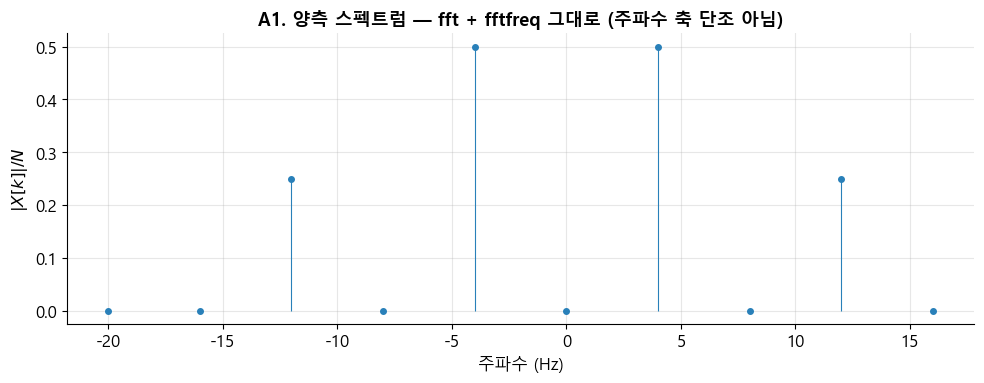

In [62]:
X  = np.fft.fft(x)
fr = np.fft.fftfreq(N, d=1/fs)

print('X  shape =', X.shape,  ' dtype =', X.dtype)
print('fr shape =', fr.shape, ' dtype =', fr.dtype)
print('fr:', fr)

# --- 시각화: fftshift 미적용 원본 순서 ---
fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, fr, np.abs(X)/N, LINE_COLORS[0])
ax.set_title('A1. 양측 스펙트럼 — fft + fftfreq 그대로 (주파수 축 단조 아님)')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('$|X[k]|/N$')
plt.tight_layout();  plt.show()

**관찰**:
- `X`(복소), `fr`(실수) 모두 길이 $N=64$로 **1:1 매칭**된다.
- `fftfreq`의 뒤 절반이 음의 주파수라 그래프가 오른쪽 절반에서 갑자기 튀어 올라 **직관적이지 않다**.
- 해석을 위해 다음 셀에서 `fftshift`로 축을 정렬한다.

### A2. 양측 스펙트럼 — `np.fft.fftshift`로 x축 정렬

`fftshift`는 배열의 앞/뒤 절반을 교환해 **음의 주파수가 왼쪽, 양의 주파수가 오른쪽**이 되도록 재정렬한다. 결과적으로 주파수 축이 $-f_s/2 \sim +f_s/2$로 단조 증가하여 시각화에 적합해진다.

In [ ]:
X_s  = np.fft.fftshift(X)
fr_s = np.fft.fftshift(fr)

print('fr_s =', np.round(fr_s, 1))
print('  → -fs/2 부터 +fs/2 까지 단조 증가 ✓')

fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, fr_s, np.abs(X_s)/N, LINE_COLORS[2])
ax.set_title('A2. 양측 스펙트럼 — fftshift 적용 ($-f_s/2 \sim +f_s/2$ 단조 정렬)')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('$|X[k]|/N$')
ax.set_xlim([-fs/2, fs/2])
plt.tight_layout();  plt.show()

**관찰**:
- $\pm 4$ Hz, $\pm 12$ Hz 네 위치에 깨끗한 피크가 **대칭**으로 나타난다.
- 실수 신호는 항상 $|X[-f]| = |X[f]|$ (켤레 대칭) — 음/양 주파수에 동일 에너지가 분포한다.
- 이 대칭성 때문에 실수 신호에서는 사실 절반만 있어도 충분하다 → 뒤의 **C1 (`rfft`)** 에서 활용한다.

### B1. 역 DFT — `np.fft.ifft` 호출

양측 스펙트럼 `X`로부터 원래 시간 신호를 복원한다. 주파수 축은 필요 없다(시간 영역 복원).

In [44]:
x_rec = np.fft.ifft(X)
print('np.fft.ifft(X) shape =', x_rec.shape, ' dtype =', x_rec.dtype)
print('복원 오차 (max) :', np.max(np.abs(x - x_rec)))
print('허수부     (max) :', np.max(np.abs(x_rec.imag)), '  (≈ 0)')

np.fft.ifft(X) shape = (10,)  dtype = complex128
복원 오차 (max) : 2.2213162975261877e-16
허수부     (max) : 1.43877537139819e-17   (≈ 0)


**관찰**: `ifft(fft(x)) = x`가 부동소수점 정밀도 내에서 완벽히 성립한다 (허수부는 수치 오차 수준 — 실제로는 `.real`을 취해 사용). 주파수 영역에서 처리 후 `ifft`로 되돌리는 것이 **FFT 기반 필터링·합성의 기본 흐름**이다 (§4.11 노이즈 제거 실습에서 활용).

### C1. 단측 스펙트럼 — `np.fft.rfft` + `np.fft.rfftfreq`

**실수 신호는 스펙트럼이 켤레 대칭이라 절반만 저장/표시하면 충분하다.** 오디오·진동·센서 등 현실의 대부분 신호가 실수이므로 **실무에서는 `rfft`를 기본으로 쓴다** (메모리·속도 모두 약 절반).

- `np.fft.rfft(x)` : 양의 주파수만 반환, 길이 $N/2+1$.
- `np.fft.rfftfreq(N, 1/fs)` : 짝이 되는 주파수 축 ($0 \sim f_s/2$), 길이 $N/2+1$ — 처음부터 단조 증가라 `fftshift` **불필요**.

In [ ]:
Xr   = np.fft.rfft(x)
fr_r = np.fft.rfftfreq(N, d=1/fs)

print('Xr   shape =', Xr.shape,   ' dtype =', Xr.dtype, '  (= N/2+1 =', N//2+1, ')')
print('fr_r shape =', fr_r.shape, ' dtype =', fr_r.dtype)
print('fr_r =', np.round(fr_r, 2))
print('  → 0 부터 fs/2 까지 단조 증가 ✓')

fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, fr_r, np.abs(Xr)/N, LINE_COLORS[0])
ax.set_title('C1. 단측 스펙트럼 — rfft + rfftfreq 그대로 ($|X_r|/N$, 2배 보정 전)')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('$|X_r[k]|/N$')
ax.set_xlim([0, fs/2])
plt.tight_layout();  plt.show()

**관찰**:
- 반환 길이는 $N/2+1 = 6$. **양측의 절반 + Nyquist 1점**만 저장한다.
- `fr_r`는 $0 \sim f_s/2$로 **이미 단조 증가**하므로 `fftshift`가 필요 없다.
- 단측으로 표시하면 진폭 해석에 **2배 보정**이 필요하다 → 다음 셀에서 처리.

### C2. 단측 스펙트럼 — 진폭 정규화 그래프

실수 신호의 에너지는 $+f$와 $-f$ 두 곳에 같은 크기로 분산되므로, 단측으로 표시할 때는 **2배 보정**해 원 신호 진폭과 일치시킨다.

$$A_k = \frac{2|X_r[k]|}{N} \quad (\text{단, DC와 Nyquist는 1배})$$

In [ ]:
# 단측 진폭 정규화 (양측 에너지 합산 → 2배), 단 DC와 Nyquist는 1배
amp = 2 * np.abs(Xr) / N
amp[0]  /= 2
amp[-1] /= 2

fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, fr_r, amp, LINE_COLORS[1])
ax.set_title('C2. 단측 진폭 스펙트럼 — $A_k = 2|X_r[k]|/N$')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('진폭')
ax.set_xlim([0, fs/2])
plt.tight_layout();  plt.show()

**관찰**: 4 Hz, 12 Hz 두 위치에 **진폭 1.0, 0.5의 깨끗한 피크** — 원 신호의 코사인 계수와 정확히 일치한다. 2배 보정을 생략하면 절반으로 관찰되어 진폭 해석이 틀어진다.

### D1. 실수 역 DFT — `np.fft.irfft` 호출

단측 스펙트럼 `Xr`로부터 실수 시간 신호를 복원한다. `n=N`을 **반드시 명시**해야 원래 길이로 복원된다(생략하면 짝수 $N$에서 한 샘플 짧아질 수 있다).

In [48]:
x_rec_r = np.fft.irfft(Xr, n=N)
print('np.fft.irfft    shape =', x_rec_r.shape, ' dtype =', x_rec_r.dtype)
print('복원 오차 (max) :', np.max(np.abs(x - x_rec_r)))

np.fft.irfft    shape = (10,)  dtype = float64
복원 오차 (max) : 3.3306690738754696e-16


**관찰**: `irfft`는 처음부터 **실수** 배열을 반환한다 (`.real` 추출 불필요), 오차는 부동소수점 정밀도 수준. 실무에서는 **`rfft` → (주파수 영역 처리) → `irfft`**가 실수 신호 처리의 **표준 파이프라인**이다 — `fft`/`ifft` 조합보다 메모리·속도 약 2배 효율.

---
## 사전 학습 — DFT 공식 직접 구현 vs `np.fft.fft`

DFT 정의식(교재 식 4.4)을 numpy 행렬 연산으로 직접 구현하고,
`np.fft.fft()`와 결과가 **부동소수점 오차 수준에서 일치**함을 확인한다.
**앞의 공통 신호 `x` (fs=40 Hz, N=10, 4 Hz + 0.5·12 Hz)** 를 그대로 재사용한다 — 두 주파수가 DFT 빈에 정확히 놓이므로 **누설이 발생하지 않는다**.

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N},
\quad k = 0, 1, \ldots, N-1 \qquad \text{(식 4.4)}$$

$N \times N$ 행렬 $W_{kn} = e^{-j2\pi kn/N}$를 이용하면
$\mathbf{X} = W \cdot \mathbf{x}$로 한 번에 계산할 수 있다.

**왜 같은 결과가 나오는가?** 기저 함수 $\{e^{j2\pi kn/N}\}_{k=0}^{N-1}$이
$N$차원 공간에서 **정규직교(orthogonal) 기저**를 이루므로,
FFT 알고리즘의 분할정복 계산은 정의식 합산과 **수학적으로 동일한 분해**를 수행한다.

직접 구현은 $O(N^2)$, FFT는 $O(N \log N)$ — 결과는 동일하지만 속도가 크게 다르다.

In [ ]:
def dft_manual(x):
    """DFT 공식 직접 구현 (식 4.4)"""
    N = len(x)
    n = np.arange(N)                          # [0, 1, ..., N-1]
    k = n.reshape((N, 1))                     # 열 벡터
    W = np.exp(-1j * 2 * np.pi * k * n / N)   # N x N 행렬
    return W @ x                              # 행렬-벡터 곱 = DFT

# 앞의 공통 신호 x, fs, N을 그대로 재사용 (fs=40 Hz, N=10, f1=4 Hz, f2=12 Hz)
X_manual = dft_manual(x)
X_fft    = np.fft.fft(x)
max_err  = np.max(np.abs(X_manual - X_fft))

print(f'수동 DFT vs np.fft.fft 최대 오차: {max_err:.2e}')
print('  → 부동소수점 정밀도 수준: 수학적으로 완전히 동일')

In [ ]:
# 두 결과를 양측 스펙트럼으로 시각화 (fftshift로 -fs/2 ~ +fs/2 정렬)
freqs_s = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
mag_m   = np.abs(np.fft.fftshift(X_manual)) / N
mag_f   = np.abs(np.fft.fftshift(X_fft))    / N

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
stem_plot(axes[0], freqs_s, mag_m, LINE_COLORS[0])
axes[0].set_title('수동 DFT (식 4.4 행렬 구현)')
axes[0].set_xlabel('주파수 (Hz)');  axes[0].set_ylabel('$|X[k]|/N$')
axes[0].set_xlim([-fs/2, fs/2])

stem_plot(axes[1], freqs_s, mag_f, LINE_COLORS[1])
axes[1].set_title('np.fft.fft() 결과')
axes[1].set_xlabel('주파수 (Hz)');  axes[1].set_ylabel('$|X[k]|/N$')
axes[1].set_xlim([-fs/2, fs/2])

fig.suptitle(f'수동 DFT vs FFT 비교 (최대 오차: {max_err:.1e})',
             fontsize=13, fontweight='bold')
plt.tight_layout();  plt.show()

**관찰**:
- 두 스펙트럼이 육안으로 완전히 일치한다. 오차는 $\sim 10^{-14}$로 **수학적으로 동일**한 결과이다.
- $\pm 4$ Hz와 $\pm 12$ Hz에 피크가 나타나며, 높이는 각각 $0.5, 0.25$로 원 신호 코사인 진폭의 절반이다 (양측 스펙트럼).
- 누설이 없으므로 피크 이외의 빈은 **정확히 0**이다.
- `np.fft.fft()`는 내부적으로 FFT 알고리즘을 써서 $O(N^2)$ 대신 $O(N \log N)$으로 계산한다.

### 직접 해보기
1. `%timeit dft_manual(x)`와 `%timeit np.fft.fft(x)`로 속도를 비교한다.
2. `x_tiny = np.array([1.0, 2.0, 3.0, 4.0])`을 손으로 계산하고 `dft_manual(x_tiny)` 결과와 비교한다.

---
## 공통 헬퍼 — 앞으로 사용할 `fft` 함수

매 실습마다 `np.fft.rfft` → 진폭 정규화 → `rfftfreq` 생성 → DC/Nyquist 보정을
반복 작성하면 코드가 번잡해진다. 이 노트북에서는 `utils.spectral.fft`를 **표준 헬퍼**로
사용한다 (이미 2번째 셀에서 임포트됨).

### 반환 규약

```python
amp, freq = fft(x, fs)
```

- `amp` : **단측 진폭 스펙트럼** — 실수, 길이 $N/2+1$, DC/Nyquist 자동 보정 완료
- `freq` : **단측 주파수 축** (0 ~ $f_s/2$), 길이 $N/2+1$

앞으로 모든 실습(1~5)에서 이 한 줄 호출을 사용한다.

### 내부 정의

참고로 `fft(x, fs)`의 구현은 다음과 같다 — 위의 사전 학습에서 배운 `np.fft.fft`,
`np.fft.rfftfreq`를 조합한 얇은 래퍼다.


In [51]:
import inspect
from utils.spectral import fft as _fft
print(inspect.getsource(_fft))


def fft(x, fs):
    """FFT 수행, 단측 진폭 스펙트럼 반환.

    Parameters
    ----------
    x : array_like
        시간 신호 (1-D)
    fs : float
        샘플링 주파수 (Hz)

    Returns
    -------
    amp : ndarray
        단측 진폭 스펙트럼 (N//2+1,)
    freq : ndarray
        주파수 축 (N//2+1,), 0 ~ fs/2
    """
    N = len(x)
    X = np.fft.fft(x)
    freq = np.fft.rfftfreq(N, d=1/fs)
    amp = 2.0 * np.abs(X[:N//2+1]) / N
    amp[0] /= 2  # DC 성분은 2배 불필요
    return amp, freq



### 1줄 사용 예제

$x[n] = \cos(2\pi \cdot 50\, n/f_s)$, $f_s=500$ Hz, $N=200$ (50 Hz가 bin 20에 정확히 정렬 — 누설 없음) →
`amp, freq = fft(x, fs)` 한 줄로 단측 스펙트럼을 얻는다. 피크는 $f=50$ Hz에서 $\approx 1.0$.

In [ ]:
fs = 500
N  = 200
t  = np.arange(N) / fs
x  = np.cos(2 * np.pi * 50 * t)

amp, freq = fft(x, fs)

fig, ax = plt.subplots(figsize=(9, 3.5))
stem_plot(ax, freq, amp, LINE_COLORS[0])
ax.set_title('amp, freq = fft(x, fs)')
ax.set_xlabel('주파수 (Hz)');  ax.set_ylabel('진폭')
plt.tight_layout();  plt.show()

**관찰**: $f=50$ Hz에서 진폭이 정확히 1.0으로 복원된다. 앞으로 이 규약(`amp, freq = fft(x, fs)`)을 모든 실습에서 사용한다.

---
## 실습 1: cos파의 FFT와 양측/단측 스펙트럼

**DFT로 $\cos(2\pi f_0 t)$를 분석하면 두 종류의 스펙트럼을 얻을 수 있다.**

오일러 공식에 의해 코사인은 두 복소지수로 분해된다:

$$\cos(2\pi f_0 t) = \frac{1}{2}e^{j2\pi f_0 t} + \frac{1}{2}e^{-j2\pi f_0 t}$$

따라서 FFT 결과에는 $+f_0$와 $-f_0$ 두 위치에 크기 $1/2$인 피크가 대칭으로 나타난다.

| 구분 | 주파수 범위 | 피크 크기 | 계산 함수 |
|------|------------|-----------|----------|
| 양측 스펙트럼 | $-f_s/2 \sim +f_s/2$ | $1/2$ | `fft` + `fftshift` |
| 단측 스펙트럼 | $0 \sim f_s/2$ | $1$ | `rfft` |

### 핵심 3성질
1. **양측 대칭**: 실수 cos → FFT에 $\pm f_0$ 대칭 피크
2. **최대 주파수**: $f_{\max} = f_s/2$ (Nyquist)
3. **주파수 분해능**: $\Delta f = f_s/N = 1/T$

In [ ]:
fs, f0, N = 500, 50, 200
t = np.arange(N) / fs
x = np.cos(2 * np.pi * f0 * t)

amp, freq   = fft(x, fs)
X_s, freq_s = fft_full(x, fs)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

stem_plot(axes[0, 0], freq_s, np.abs(X_s) / N, LINE_COLORS[0])
axes[0, 0].set_title('(a) 양측 스펙트럼')
axes[0, 0].set_xlabel('주파수 (Hz)');  axes[0, 0].set_ylabel('$|X|/N$')

stem_plot(axes[0, 1], freq, amp, LINE_COLORS[1])
axes[0, 1].set_title('(b) 단측 스펙트럼')
axes[0, 1].set_xlabel('주파수 (Hz)');  axes[0, 1].set_ylabel('진폭')

stem_plot(axes[1, 0], freq, amp, LINE_COLORS[2])
axes[1, 0].axvline(fs/2, color=COLORS['warning'], ls='--', lw=1)
axes[1, 0].set_title(f'(c) Nyquist = {fs//2} Hz')
axes[1, 0].set_xlabel('주파수 (Hz)');  axes[1, 0].set_ylabel('진폭')

N_hd = 2000
x_hd = np.cos(2 * np.pi * f0 * np.arange(N_hd) / fs)
am_hd, fr_hd = fft(x_hd, fs)
mask = (fr_hd >= 49) & (fr_hd <= 51)
stem_plot(axes[1, 1], fr_hd[mask], am_hd[mask], LINE_COLORS[3])
axes[1, 1].set_title(f'(d) 확대: $N={N_hd}$, $\\Delta f={fs/N_hd}$ Hz')
axes[1, 1].set_xlabel('주파수 (Hz)');  axes[1, 1].set_ylabel('진폭')

plt.tight_layout();  plt.show()

**관찰**:
- **(a)** $+50$ Hz와 $-50$ Hz에 각각 높이 $0.5$의 피크가 대칭으로 나타난다.
- **(b)** $+50$ Hz에만 높이 $1.0$의 피크가 나타난다 (음의 주파수 에너지를 합산).
- **(c)** $f_0=50$ Hz $< f_s/2=250$ Hz이므로 에일리어싱 없이 정확히 분석된다.
- **(d)** $N$을 10배 늘리면 $\Delta f = 500/2000 = 0.25$ Hz로 분해능이 향상된다.
- $N=200, 2000$ 모두 50 Hz가 bin에 정확히 놓이도록 선택해 **누설이 발생하지 않는다**.

### 직접 해보기
1. `f0 = 60.5`로 바꾸면(비정수 주기) 단일 피크 대신 에너지가 퍼지는 현상(누설)을 관찰한다.
2. `N = 512`로 늘리면 분해능은 향상되지만 50 Hz가 bin에 맞지 않아 누설이 생긴다 — 누설과 분해능은 별개 개념이다.

---
## 실습 2: 두 개의 근접 주파수 분리

주파수 분해능 $\Delta f = f_s / N = 1/T$는 두 주파수를 구분하는 최소 간격이다.

100 Hz와 105 Hz (간격 5 Hz)를 분리하려면 $\Delta f \leq 5$ Hz가 필요하다:

$$\Delta f = \frac{f_s}{N} \leq 5 \text{ Hz}
\quad \Rightarrow \quad N \geq \frac{1000}{5} = 200$$

**누설을 피하기 위해** 아래 세 $N$ 값에서 100 Hz와 105 Hz가 **모두 bin에 정확히 정렬**되도록 선택했다
(fs=1000에서 105 Hz가 정수 bin에 오려면 $N$이 200의 배수여야 한다).

| $N$ | $\Delta f$ | 100 Hz bin | 105 Hz bin | 100 + 105 Hz 분리 |
|-----|-----------|-----------|------------|-------------------|
| 200 | 5.0 Hz    | 20        | 21         | 경계 (인접 빈)    |
| 400 | 2.5 Hz    | 40        | 42         | 가능              |
| 1000| 1.0 Hz    | 100       | 105        | 매우 선명         |

In [ ]:
fs = 1000
f1, f2 = 100, 105

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for idx, N in enumerate([200, 400, 1000]):
    t = np.arange(N) / fs
    amp, freq = fft(np.cos(2*np.pi*f1*t), fs)
    stem_plot(axes[0, idx], freq, amp, LINE_COLORS[idx])
    axes[0, idx].set_title(f'단일 100 Hz — $N={N}$')
    axes[0, idx].set_xlabel('주파수 (Hz)');  axes[0, idx].set_ylabel('진폭')
    axes[0, idx].set_xlim([0, 250])

for idx, N in enumerate([200, 400, 1000]):
    t = np.arange(N) / fs
    x = np.cos(2*np.pi*f1*t) + np.cos(2*np.pi*f2*t)
    amp, freq = fft(x, fs)
    stem_plot(axes[1, idx], freq, amp, LINE_COLORS[idx])
    axes[1, idx].set_title(f'100+105 Hz — $N={N}$, $\\Delta f={fs/N:.1f}$ Hz')
    axes[1, idx].set_xlabel('주파수 (Hz)');  axes[1, idx].set_ylabel('진폭')
    axes[1, idx].set_xlim([80, 130])

plt.tight_layout();  plt.show()

**관찰**:
- **상단 행**: 단일 100 Hz 신호 — 세 경우 모두 bin 정렬 → 누설 없이 단일 피크.
- **하단 행**: 100 Hz + 105 Hz 혼합 신호.
  - $N=200$ ($\Delta f=5$ Hz = 간격): 두 피크가 **인접 빈**(20, 21)에 놓여 경계 상태로 구분.
  - $N=400$ ($\Delta f=2.5$ Hz $<5$): 빈 사이에 간격이 생겨 선명히 분리.
  - $N=1000$ ($\Delta f=1$ Hz $\ll 5$): 매우 깨끗하게 분리.

**결론**: $N$ 증가 = 관측 시간 $T$ 증가 = 분해능 향상. 세 경우 모두 주파수가 bin에 정렬되어 누설 없이 분해능 효과만 단독 관찰할 수 있다.

### 직접 해보기
1. `N = 100` (Δf=10 Hz > 간격)으로 바꾸면 어떻게 되는가? 이때 105 Hz가 bin에 정렬되지 않아 누설도 함께 발생한다.
2. `f1, f2 = 100, 101` (간격 1 Hz)로 바꾸면 분리 가능한 최소 $N$은? 이론값 $N \geq f_s/(f_2-f_1)$과 비교.

---
## 실습 3: 합성 음성의 FFT 스펙트럼

사람의 목소리는 **기본 주파수** $f_0$와 그 정수배인 **고조파(harmonics)**의 합으로 근사된다:

$$x(t) = \sum_{h=1}^{H} A_h \sin(2\pi h f_0 t)$$

- 모음 /a/의 기본 주파수: 약 $f_0 = 150$ Hz (남성 기준)
- FFT 스펙트럼에서 $f_0, 2f_0, 3f_0, \ldots$ 위치에 규칙적인 피크가 나타난다
- 고조파 번호가 높을수록 진폭이 작아져 풍부한 음색을 만든다

In [ ]:
fs, T, f0 = 16000, 0.04, 150
N = int(fs * T)
t = np.arange(N) / fs

harmonics = [1, 2, 3, 4, 5, 6, 7, 8]
amps      = [1.0, 0.7, 0.5, 0.35, 0.25, 0.15, 0.1, 0.05]
x = sum(a * np.sin(2*np.pi*f0*h*t) for h, a in zip(harmonics, amps))

amp, freq = fft(x, fs)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(t * 1000, x, color=LINE_COLORS[0], lw=1.2)
axes[0].set_title(f'(a) 합성 음성 $f_0={f0}$ Hz + 8 고조파')
axes[0].set_xlabel('시간 (ms)');  axes[0].set_ylabel('진폭')

mask = freq <= 2000
stem_plot(axes[1], freq[mask], amp[mask], LINE_COLORS[1], markersize=2)
axes[1].set_title('(b) FFT 스펙트럼')
axes[1].set_xlabel('주파수 (Hz)');  axes[1].set_ylabel('진폭')

plt.tight_layout();  plt.show()

**관찰**:
- **(a)** 여러 주파수 성분이 합산되어 복잡한 파형을 형성한다. 주기 $\approx 1/f_0 = 6.67$ ms.
- **(b)** $f_0=150$ Hz, $2f_0=300$ Hz, $3f_0=450$ Hz ... 에 규칙적 피크. 고조파 번호가 클수록 진폭이 감소한다.

### 직접 해보기
1. `f0 = 200`으로 바꾸면 고조파 피크 위치가 어떻게 이동하는가?
2. `amps`를 모두 동일하게(예: 모두 `0.5`)로 바꾸면 스펙트럼 모양이 어떻게 달라지는가?

---
## 실습 4: FFT 기반 노이즈 필터링

**원리**: 주파수 영역에서 원하지 않는 성분을 제거하고 IFFT로 복원한다.

$$x_{\text{noisy}}[n]
\xrightarrow{\text{FFT}} X[k]
\xrightarrow{\text{임계값 필터}} \hat{X}[k]
\xrightarrow{\text{IFFT}} \hat{x}[n]$$

- 노이즈: 전 주파수에 골고루 분산 → 각 빈의 진폭이 작다
- 신호: 특정 주파수에 집중 → 진폭이 크다
- 임계값으로 신호와 노이즈를 분리할 수 있다

In [ ]:
fs, N = 1000, 1000
t = np.arange(N) / fs

x_clean = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)
np.random.seed(42)
x_noisy = x_clean + 0.8 * np.random.randn(N)

# 임계값 필터링
threshold = 0.3
X = np.fft.rfft(x_noisy)
X[2 * np.abs(X) / N < threshold] = 0
x_filtered = np.fft.irfft(X, n=N)

amp_n, freq = fft(x_noisy, fs)
amp_f       = 2 * np.abs(X) / N
amp_f[0] /= 2;  amp_f[-1] /= 2

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0, 0].plot(t, x_clean, color=LINE_COLORS[0], lw=1.2)
axes[0, 0].set_title('(a) 원 신호')
axes[0, 0].set_xlabel('시간 (s)');  axes[0, 0].set_ylabel('진폭')

axes[0, 1].plot(t, x_noisy, color=LINE_COLORS[3], lw=0.8)
axes[0, 1].set_title('(b) 노이즈 추가')
axes[0, 1].set_xlabel('시간 (s)');  axes[0, 1].set_ylabel('진폭')

mask = freq <= 250
axes[1, 0].plot(freq[mask], amp_n[mask], color=LINE_COLORS[3], lw=0.8, alpha=0.6)
axes[1, 0].plot(freq[mask], amp_f[mask], color=LINE_COLORS[2], lw=1.5)
axes[1, 0].axhline(threshold, color=COLORS['warning'], ls='--', lw=1)
axes[1, 0].set_title(f'(c) 스펙트럼 — 임계값 {threshold}')
axes[1, 0].set_xlabel('주파수 (Hz)');  axes[1, 0].set_ylabel('진폭')

axes[1, 1].plot(t, x_clean, color=LINE_COLORS[0], lw=1.2, alpha=0.5)
axes[1, 1].plot(t, x_filtered, color=LINE_COLORS[2], lw=1.2, ls='--')
axes[1, 1].set_title('(d) IFFT 복원')
axes[1, 1].set_xlabel('시간 (s)');  axes[1, 1].set_ylabel('진폭')

plt.tight_layout();  plt.show()

**관찰**:
- **(b)** 노이즈 추가 후 원래 신호 형태를 알아보기 어렵다.
- **(c)** 50 Hz와 120 Hz 피크는 임계값 위에, 노이즈는 임계값 아래에 분포한다.
- **(d)** IFFT 복원 결과가 원래 깨끗한 신호와 거의 일치한다.

**한계**: 신호와 노이즈의 주파수 대역이 겹치면 효과가 감소한다. 더 정교한 필터링은 Ch6(디지털 필터 설계)에서 다룬다.

### 직접 해보기
1. `threshold = 0.6`으로 올리면 복원 신호가 어떻게 달라지는가?
2. 노이즈 진폭을 `0.8`에서 `0.1`로 줄이면 필터 없이도 신호를 구분할 수 있는가?

---
## 정리

| 절 | 핵심 개념 | 결과 |
|----|-----------|------|
| 사전 학습 A–D | NumPy FFT 함수군 | 변환 ↔ 주파수 축 1:1 매핑, fftshift 정렬, 단측 2배 보정 |
| 사전 학습 (수동 DFT) | DFT 정의식 직접 구현 | 수동 행렬 구현 = `np.fft.fft` (부동소수점 정밀도) |
| 실습 1 | 양측/단측 스펙트럼 | cos → $\pm f_0$ 대칭, rfft로 단측 변환 |
| 실습 2 | 주파수 분해능 | $\Delta f = f_s/N$; $N$ 클수록 근접 주파수 분리 |
| 실습 3 | 합성 음성 FFT | 고조파 구조가 스펙트럼에 규칙적 피크로 드러남 |
| 실습 4 | FFT 필터링 | 임계값 필터 + IFFT로 노이즈 제거 |

### 핵심 수식

**DFT 정의** (식 4.4):
$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N}$$

**주파수 대응**:
$$f_k = k \cdot \frac{f_s}{N}, \quad \Delta f = \frac{f_s}{N} = \frac{1}{T}$$

**단측 스펙트럼** (실수 신호, $k \neq 0, N/2$):
$$A_k = \frac{2|X[k]|}{N}$$

### NumPy FFT 함수

```python
np.fft.fft(x)            # DFT — 복소수, 길이 N
np.fft.ifft(X)           # IDFT
np.fft.rfft(x)           # 실수 신호 DFT — 길이 N//2+1
np.fft.irfft(X, n=N)     # 실수 신호 IDFT
np.fft.fftfreq(N, 1/fs)  # 주파수 축
np.fft.rfftfreq(N, 1/fs) # 단측 주파수 축
np.fft.fftshift(X)       # 양측 스펙트럼 정렬
```

### 다음 실습 예고

Ch5에서는 스펙트럼 누설을 줄이는 **윈도우 함수**(Hann, Hamming, Blackman 등)의
특성과 선택 기준을 다룬다.
윈도우를 적용하면 누설이 줄지만 분해능이 약간 낮아지는 트레이드오프를 직접 확인한다.